In [1]:
import random
from pathlib import Path

import joblib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
model = joblib.load("../models/knn_landcover_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
def extract_features(image_path):

    image = Image.open(image_path).convert("RGB")
    image = image.resize((64, 64))

    image_array = np.array(image)

    mean_r = image_array[:, :, 0].mean()
    mean_g = image_array[:, :, 1].mean()
    mean_b = image_array[:, :, 2].mean()

    std_r = image_array[:, :, 0].std()
    std_g = image_array[:, :, 1].std()
    std_b = image_array[:, :, 2].std()

    brightness = image_array.mean()

    features = np.array([
        mean_r,
        mean_g,
        mean_b,
        std_r,
        std_g,
        std_b,
        brightness
    ])

    return features

In [4]:
data_dir = Path("../data/raw/eurosat_subset")

class_names = [
    "Forest",
    "River",
    "Residential"
]

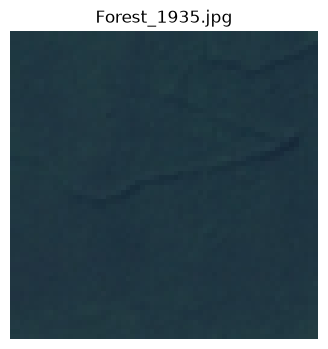

Image:          Forest_1935.jpg
Actual Label:   Forest
Prediction:     Forest
Status:         ✅ Correct


/Users/radha/Documents/satellite-landcover-knn/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


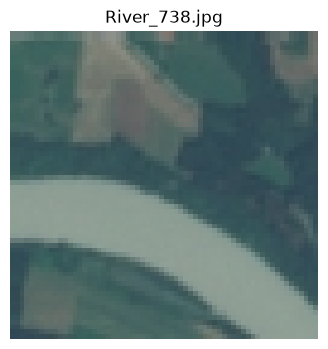

Image:          River_738.jpg
Actual Label:   River
Prediction:     River
Status:         ✅ Correct


/Users/radha/Documents/satellite-landcover-knn/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


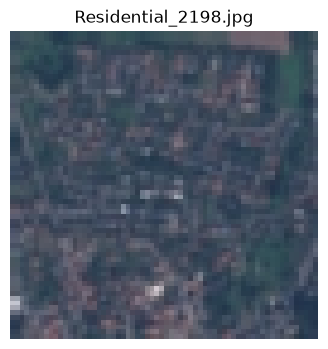

/Users/radha/Documents/satellite-landcover-knn/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Image:          Residential_2198.jpg
Actual Label:   Residential
Prediction:     Residential
Status:         ✅ Correct


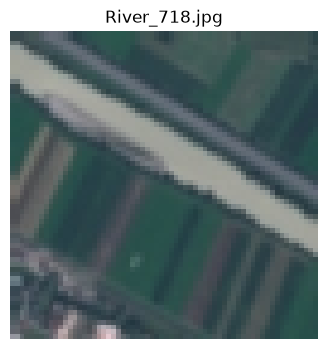

/Users/radha/Documents/satellite-landcover-knn/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Image:          River_718.jpg
Actual Label:   River
Prediction:     River
Status:         ✅ Correct


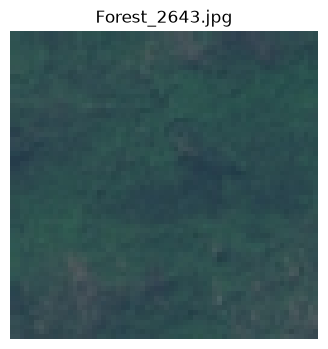

Image:          Forest_2643.jpg
Actual Label:   Forest
Prediction:     Forest
Status:         ✅ Correct


/Users/radha/Documents/satellite-landcover-knn/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [5]:
for i in range(5):

    print("=" * 60)

    # Choose random class
    actual_label = random.choice(class_names)

    # Choose random image
    image_path = random.choice(
        list((data_dir / actual_label).glob("*.jpg"))
    )

    # Display image
    image = Image.open(image_path)

    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_path.name)
    plt.show()

    # Extract features
    features = extract_features(image_path)

    # Predict
    prediction = model.predict([features])[0]

    # Display results
    print(f"Image:          {image_path.name}")
    print(f"Actual Label:   {actual_label}")
    print(f"Prediction:     {prediction}")

    if prediction == actual_label:
        print("Status:         ✅ Correct")
    else:
        print("Status:         ❌ Incorrect")

In [9]:
import pandas as pd

correct = 0
total = 100  # Increase for a more reliable estimate

feature_names = [
    "Mean_R",
    "Mean_G",
    "Mean_B",
    "Std_R",
    "Std_G",
    "Std_B",
    "Brightness"
]

for i in range(total):

    # Choose a random class
    actual_label = random.choice(class_names)

    # Choose a random image from that class
    image_path = random.choice(
        list((data_dir / actual_label).glob("*.jpg"))
    )

    # Extract image features
    features = extract_features(image_path)

    # Convert features into a DataFrame
    feature_df = pd.DataFrame([features], columns=feature_names)

    # Predict
    prediction = model.predict(feature_df)[0]

    if prediction == actual_label:
        correct += 1

print("=" * 50)
print(f"Images Tested: {total}")
print(f"Correct Predictions: {correct}")
print(f"Demo Accuracy: {(correct/total)*100:.2f}%")
print("=" * 50)

Images Tested: 100
Correct Predictions: 95
Demo Accuracy: 95.00%


In [12]:
print("=" * 60)
print("Satellite Land Cover Prediction Demo")
print(f"Images Tested      : {total}")
print(f"Correct Predictions: {correct}")
print(f"Incorrect Predictions: {total - correct}")
print(f"Demo Accuracy      : {(correct/total)*100:.2f}%")
print("=" * 60)

Satellite Land Cover Prediction Demo
Images Tested      : 100
Correct Predictions: 95
Incorrect Predictions: 5
Demo Accuracy      : 95.00%
